In [1]:
import xarray as xr

from dask.distributed import Client, LocalCluster

cluster = LocalCluster(
    n_workers=30, 
    threads_per_worker=1,
    memory_limit="auto",
    local_directory="/tmp/dask",
    dashboard_address=":8787",
)

client = Client(cluster)

In [3]:
ds_arctic_subset = xr.open_dataset("data/era5_arctic_subset.nc", chunks='auto')

In [4]:
ds_arctic_subset_sic = ds_arctic_subset['sea_ice_cover']
ds_arctic_subset_sic

<xarray.DataArray 'sea_ice_cover' (time: 58448, longitude: 128, latitude: 11)> Size: 329MB
dask.array<open_dataset-sea_ice_cover, shape=(58448, 128, 11), dtype=float32, chunksize=(44618, 94, 8), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 88B 61.43 64.29 67.14 ... 84.29 87.14 90.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) datetime64[ns] 468kB 1980-01-01 ... 2020-01-02T18:00:00
Attributes:
    long_name:      Sea ice area fraction
    short_name:     siconc
    standard_name:  sea_ice_area_fraction
    units:          (0 - 1)

In [5]:
ds_arcitc_season = ds_arctic_subset.groupby('time.season')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


seasons = ['DJF', 'MAM', 'JJA', 'SON']
decades = pd.date_range(start='1980-01-01', end='2020-01-01', freq='1YS')
sea_ice_covers = np.arange(0, 1.1, 0.1)
levels = ds_arctic_subset['level']

decade_bins = pd.cut(decades, bins=decades)[1:]
decade_mids = [decade.mid for decade in decade_bins]

sea_ice_cover_bins = pd.cut(sea_ice_covers, bins=sea_ice_covers)[1:]
sea_ice_cover_mids = [sea_ice_cover.mid for sea_ice_cover in sea_ice_cover_bins]

ds_out = xr.Dataset(
    coords={
        'season': seasons,
        'decade': decade_mids,
        'sea_ice_cover': sea_ice_cover_mids,
        'level' : levels,
    },
    data_vars={
        't' : (['season', 'decade', 'sea_ice_cover', 'level'], np.zeros((len(seasons), len(decade_mids), len(sea_ice_cover_mids), len(levels)))),
        'q' : (['season', 'decade', 'sea_ice_cover', 'level'], np.zeros((len(seasons), len(decade_mids), len(sea_ice_cover_mids), len(levels)))),
    }

)

for season, ds in ds_arcitc_season:

    ds_decade = ds.groupby_bins('time', bins=decades)
    for decade, ds in ds_decade:
        print(decade, season)

        str_decade = decade.mid
        ds_gp_sic = ds.groupby_bins('sea_ice_cover', bins=sea_ice_covers).mean()
        ds_out['t'].loc[{'season': season, 'decade': str_decade}] = ds_gp_sic['temperature'].values.T
        ds_out['q'].loc[{'season': season, 'decade': str_decade}] = ds_gp_sic['specific_humidity'].values.T

(1980-01-01 00:00:00, 1981-01-01 00:00:00] DJF
(1981-01-01 00:00:00, 1982-01-01 00:00:00] DJF
(1982-01-01 00:00:00, 1983-01-01 00:00:00] DJF
(1983-01-01 00:00:00, 1984-01-01 00:00:00] DJF
(1984-01-01 00:00:00, 1985-01-01 00:00:00] DJF
(1985-01-01 00:00:00, 1986-01-01 00:00:00] DJF
(1986-01-01 00:00:00, 1987-01-01 00:00:00] DJF
(1987-01-01 00:00:00, 1988-01-01 00:00:00] DJF
(1988-01-01 00:00:00, 1989-01-01 00:00:00] DJF
(1989-01-01 00:00:00, 1990-01-01 00:00:00] DJF
(1990-01-01 00:00:00, 1991-01-01 00:00:00] DJF
(1991-01-01 00:00:00, 1992-01-01 00:00:00] DJF
(1992-01-01 00:00:00, 1993-01-01 00:00:00] DJF
(1993-01-01 00:00:00, 1994-01-01 00:00:00] DJF
(1994-01-01 00:00:00, 1995-01-01 00:00:00] DJF
(1995-01-01 00:00:00, 1996-01-01 00:00:00] DJF
(1996-01-01 00:00:00, 1997-01-01 00:00:00] DJF
(1997-01-01 00:00:00, 1998-01-01 00:00:00] DJF
(1998-01-01 00:00:00, 1999-01-01 00:00:00] DJF
(1999-01-01 00:00:00, 2000-01-01 00:00:00] DJF
(2000-01-01 00:00:00, 2001-01-01 00:00:00] DJF
(2001-01-01 0

In [6]:
ds_out.isel(season=0, decade=0)

<xarray.Dataset> Size: 2kB
Dimensions:        (sea_ice_cover: 10, level: 13)
Coordinates:
  * level          (level) int64 104B 50 100 150 200 250 ... 700 850 925 1000
    season         <U3 12B 'DJF'
    decade         datetime64[ns] 8B 1980-07-02
  * sea_ice_cover  (sea_ice_cover) float64 80B 0.05 0.15 0.25 ... 0.75 0.85 0.95
Data variables:
    t              (sea_ice_cover, level) float64 1kB 200.5 207.0 ... 249.0
    q              (sea_ice_cover, level) float64 1kB 2.87e-06 ... 0.0004425

In [7]:
ds_arctic_subset.specific_humidity

<xarray.DataArray 'specific_humidity' (time: 58448, level: 13, longitude: 128,
                                       latitude: 11)> Size: 4GB
dask.array<open_dataset-specific_humidity, shape=(58448, 13, 128, 11), dtype=float32, chunksize=(28923, 5, 58, 4), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 88B 61.43 64.29 67.14 ... 84.29 87.14 90.0
  * level      (level) int64 104B 50 100 150 200 250 ... 600 700 850 925 1000
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) datetime64[ns] 468kB 1980-01-01 ... 2020-01-02T18:00:00
Attributes:
    long_name:      Specific humidity
    short_name:     q
    standard_name:  specific_humidity
    units:          kg kg**-1

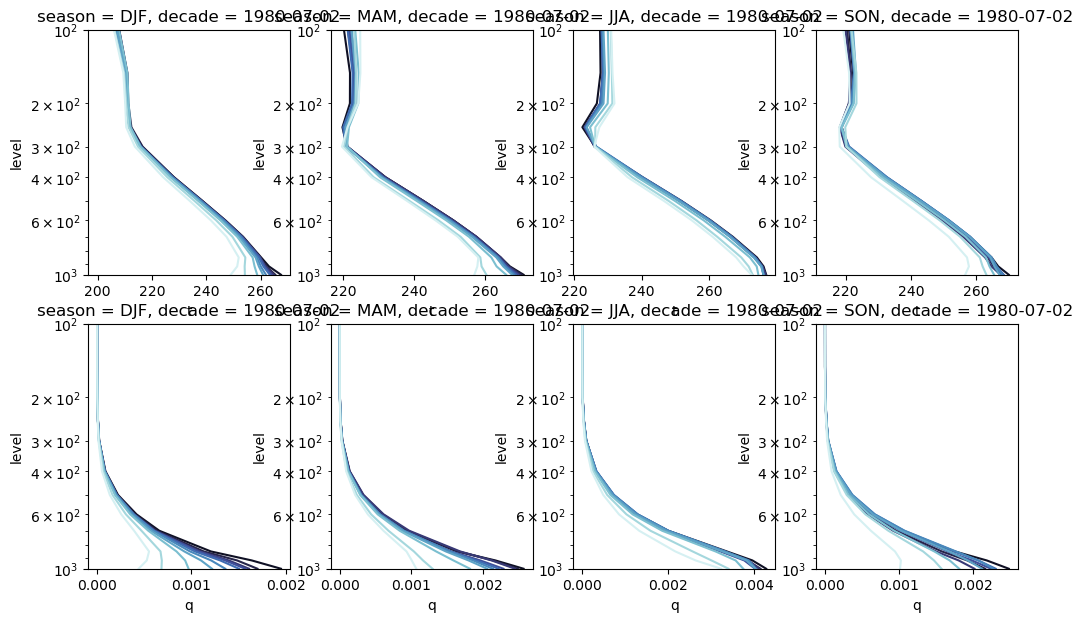

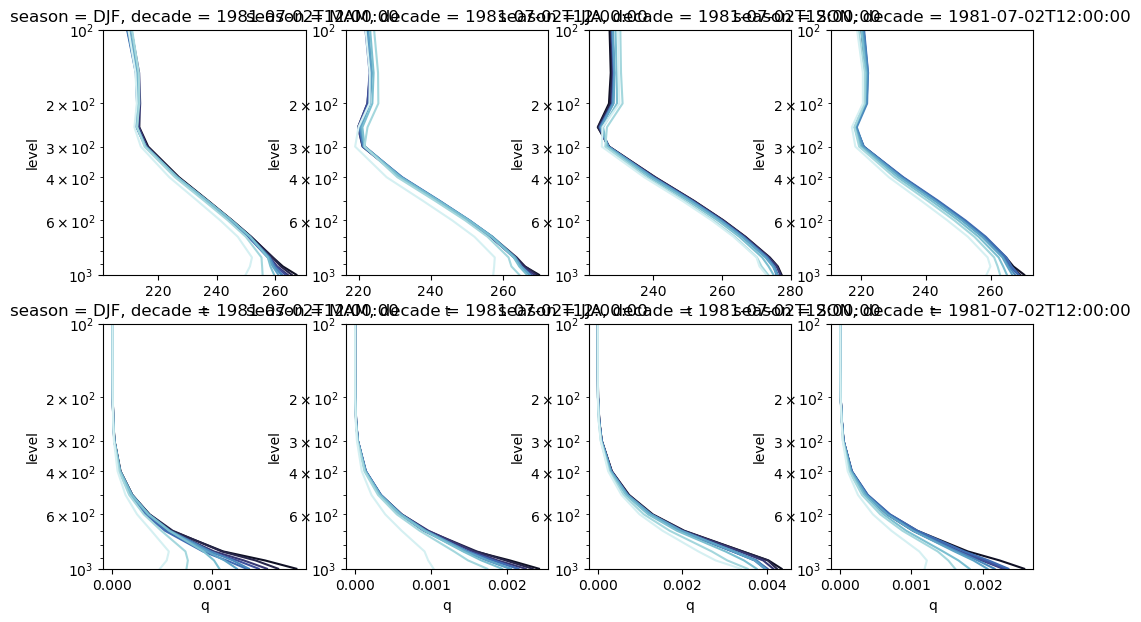

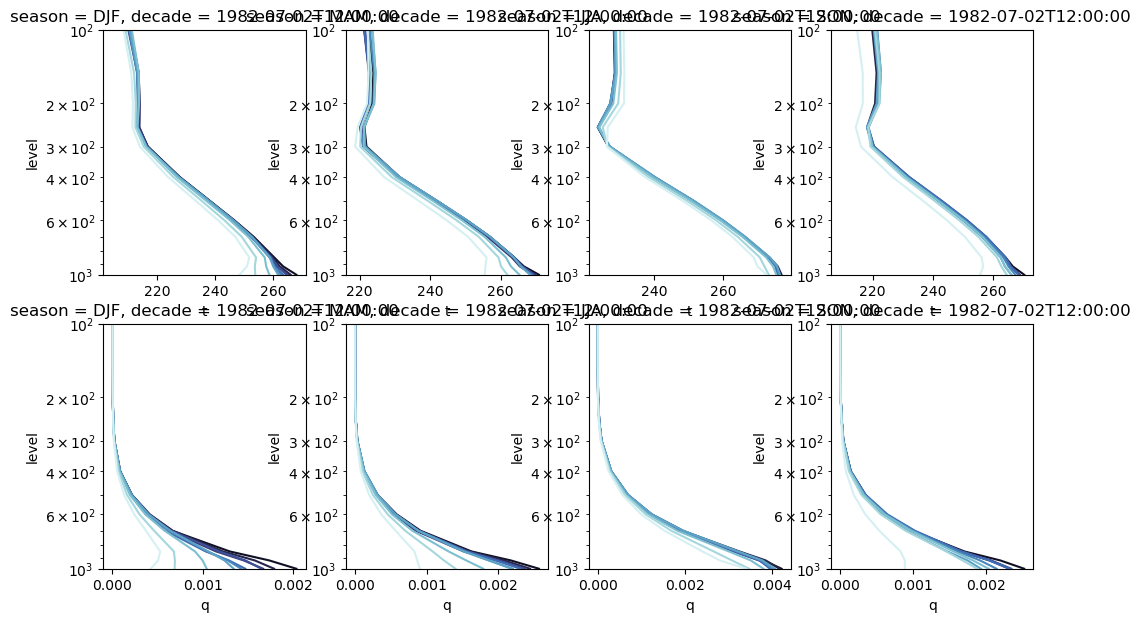

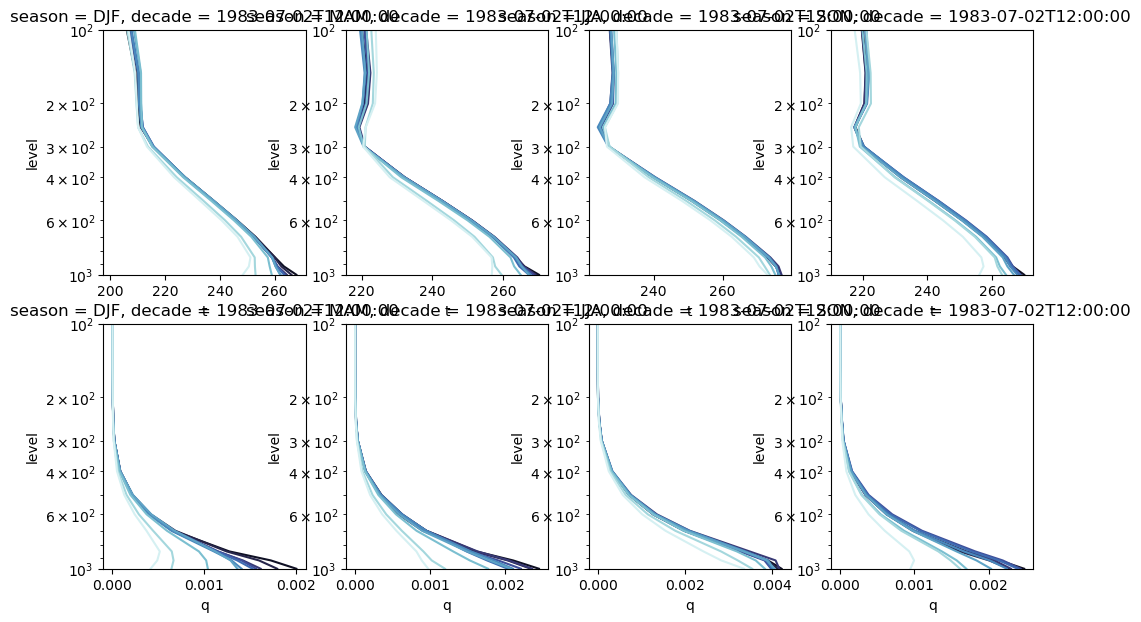

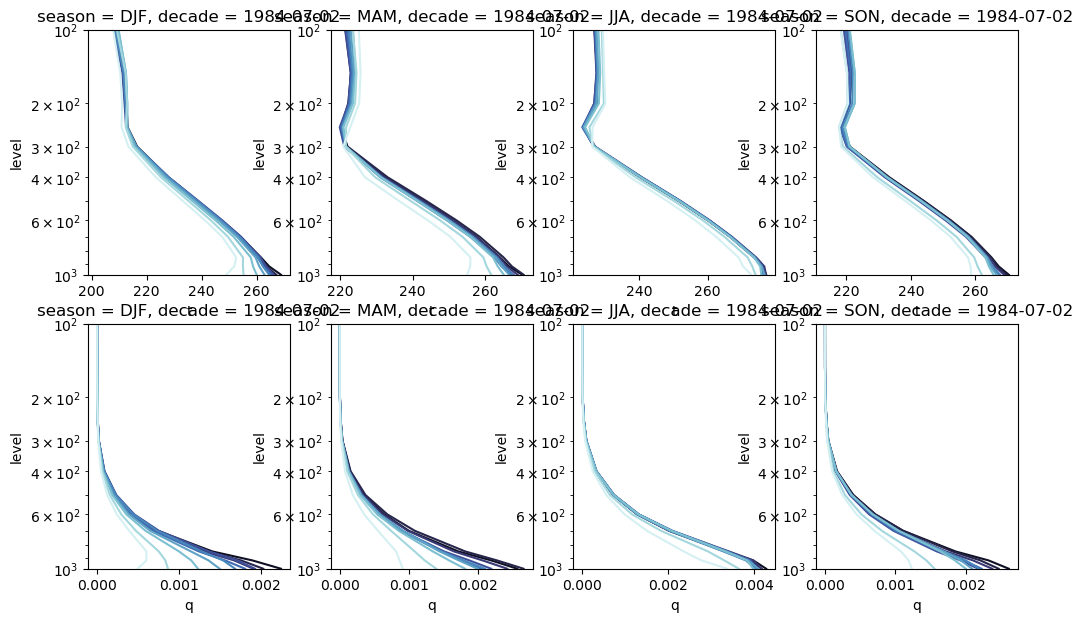

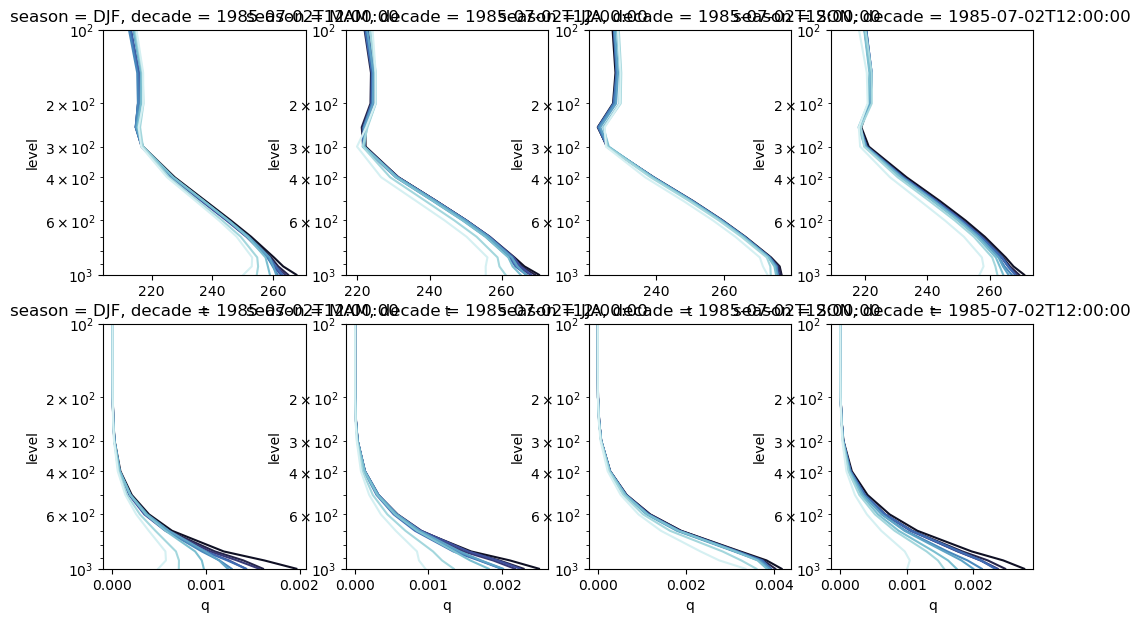

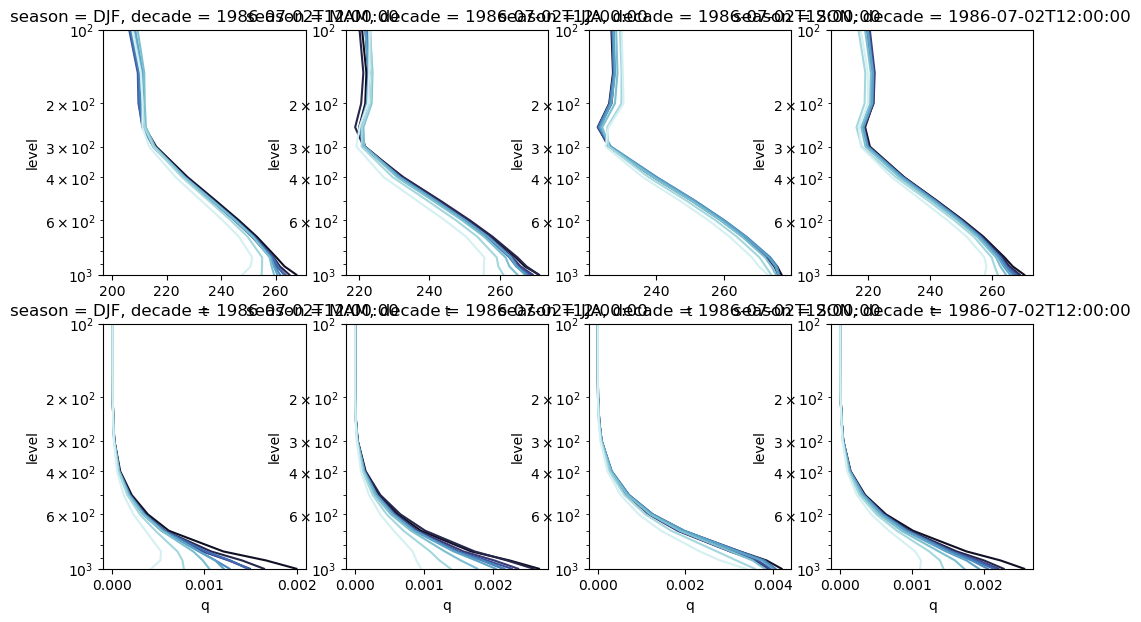

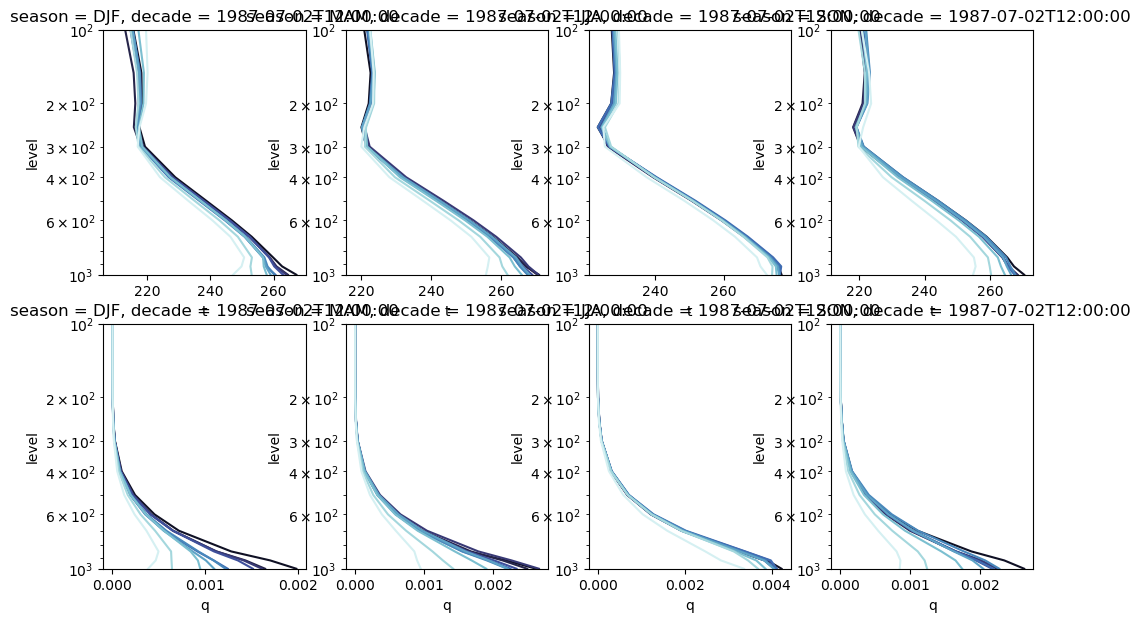

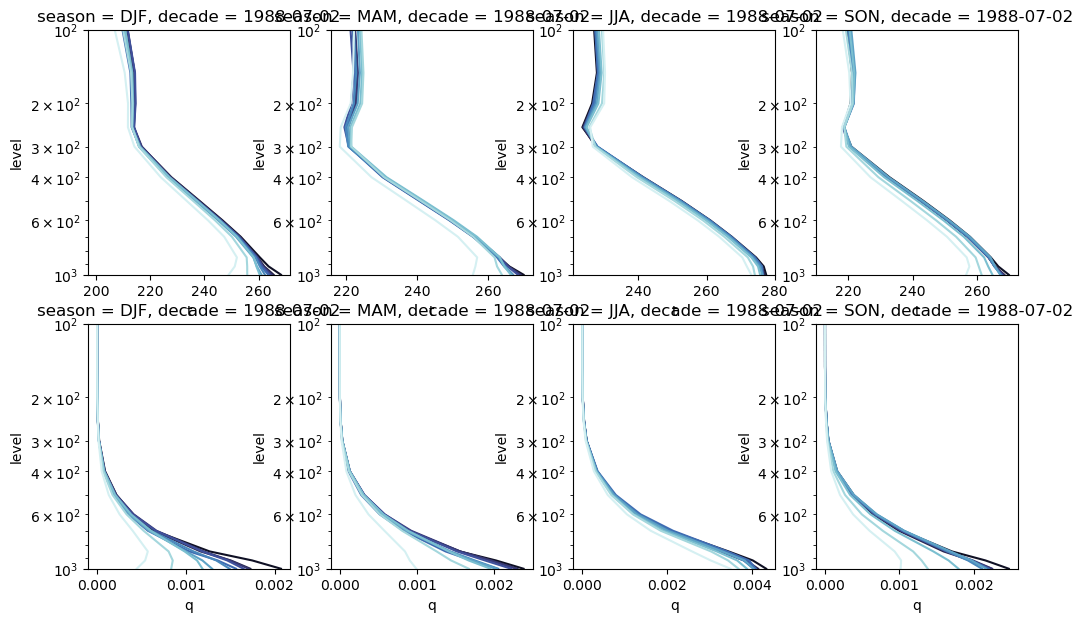

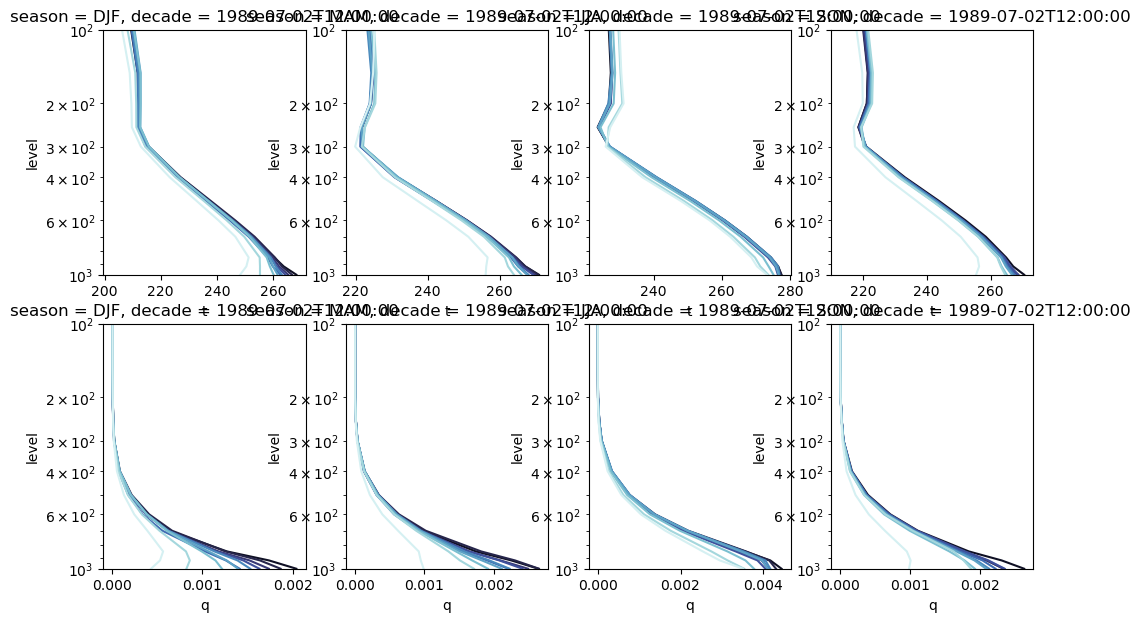

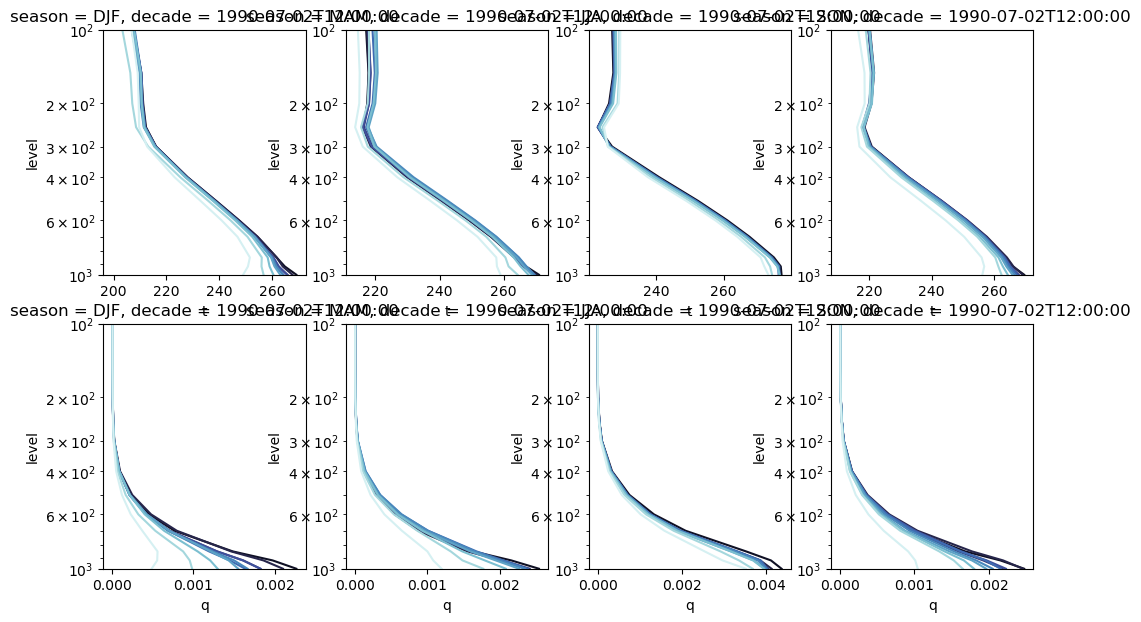

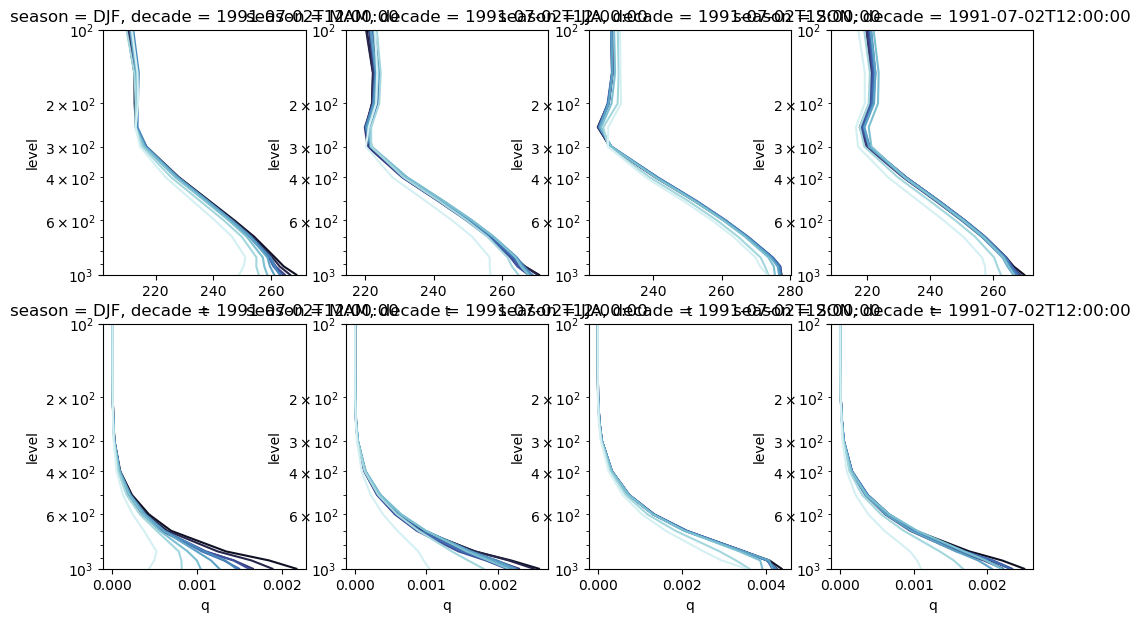

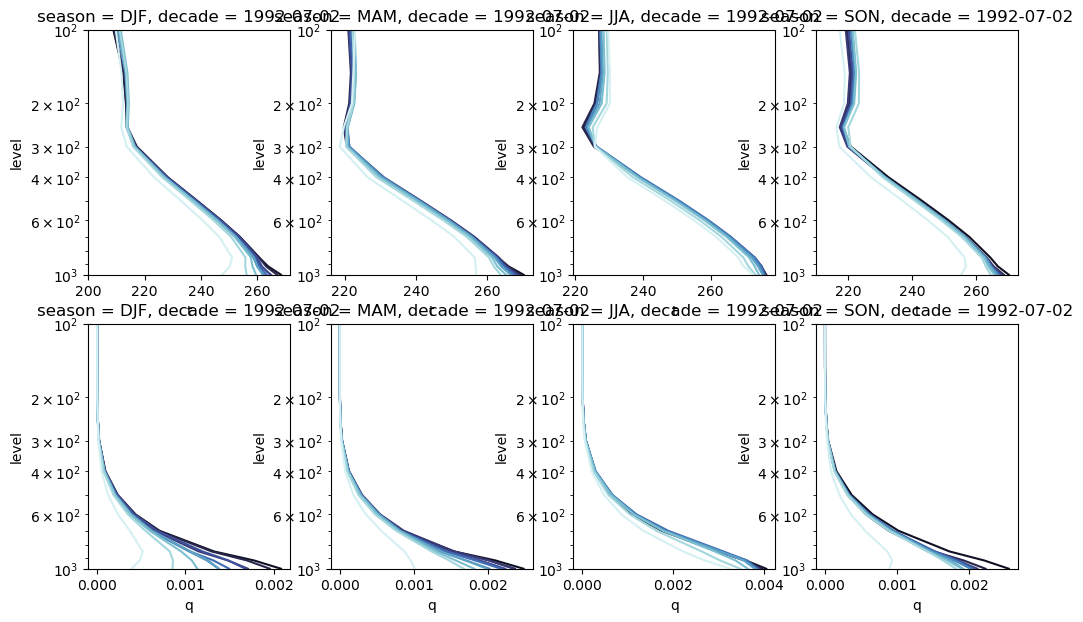

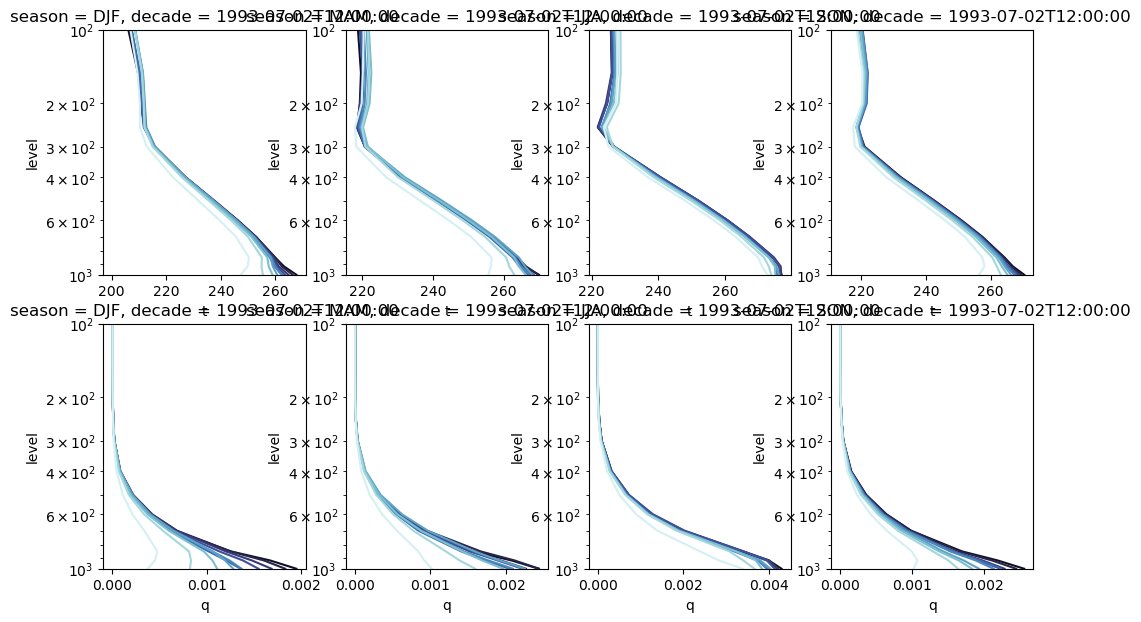

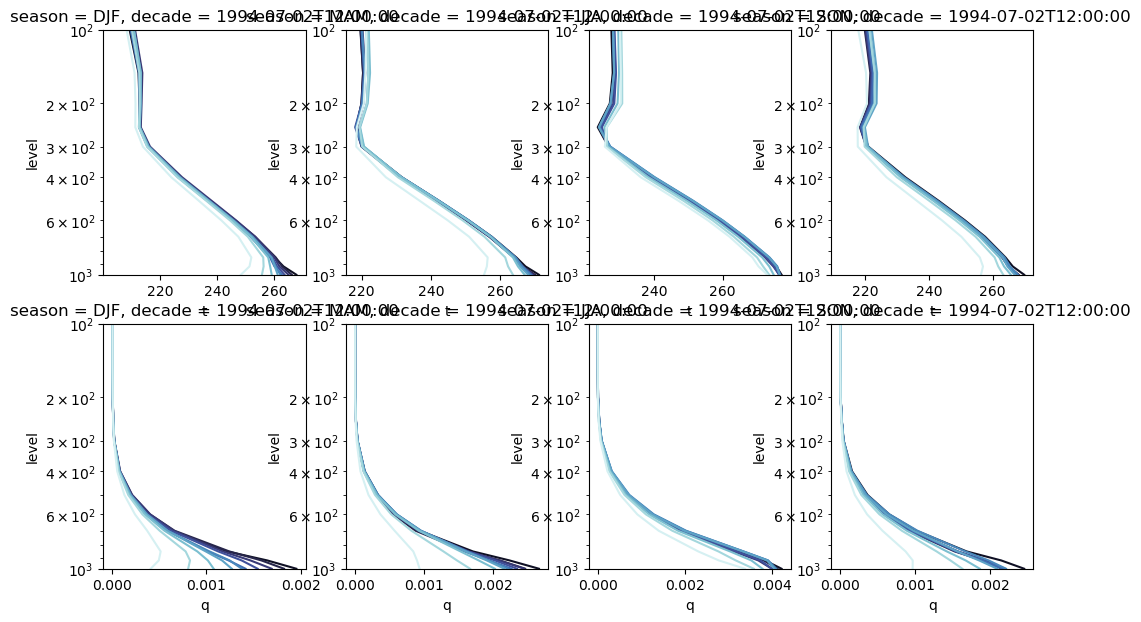

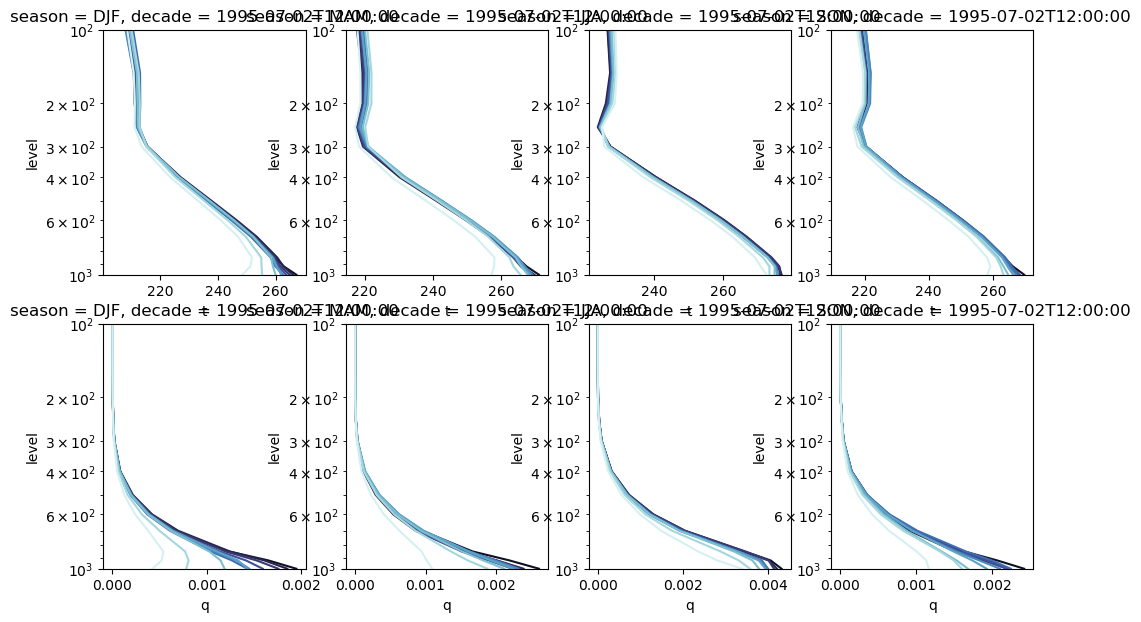

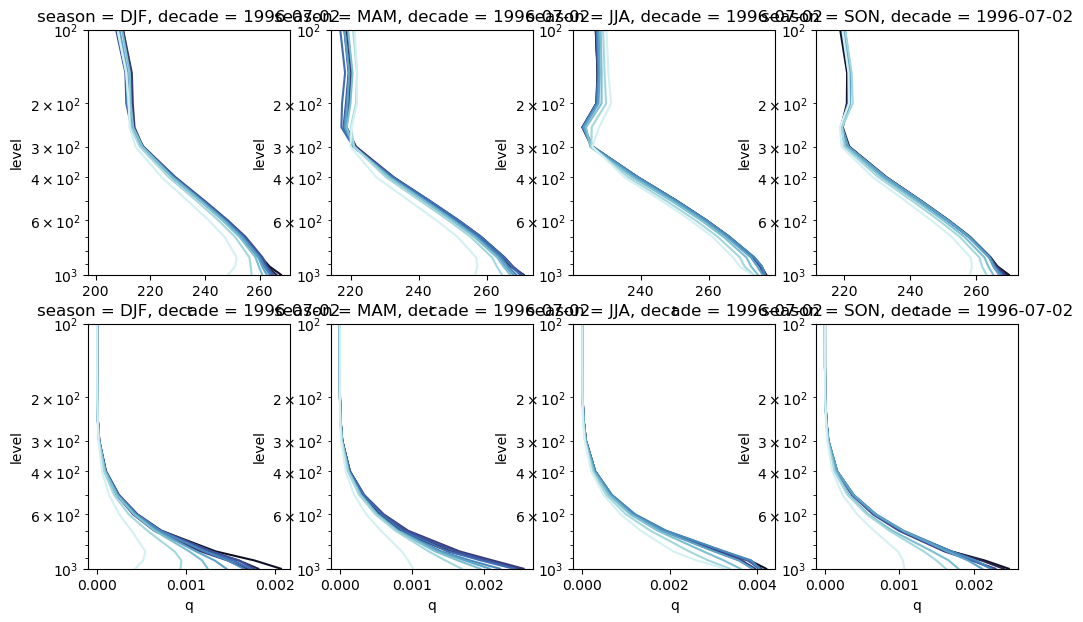

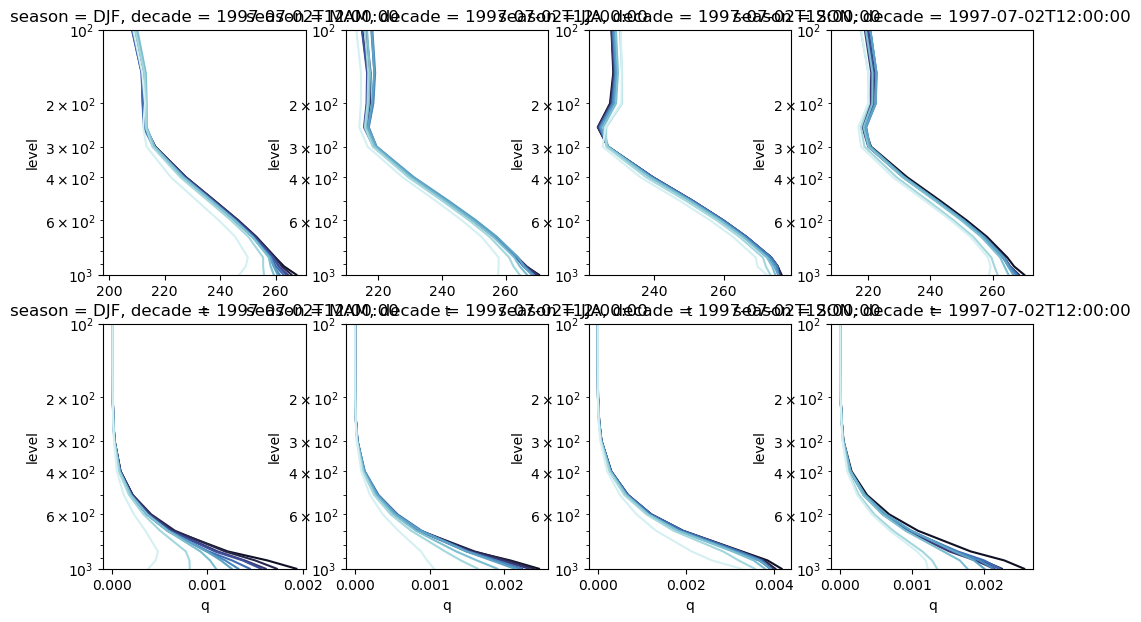

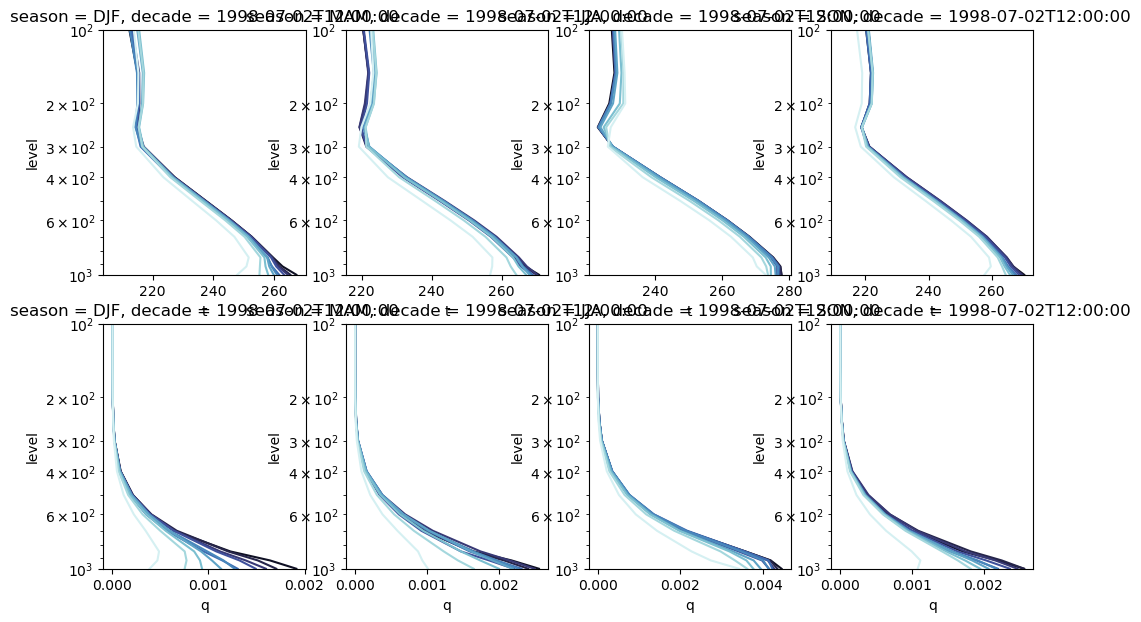

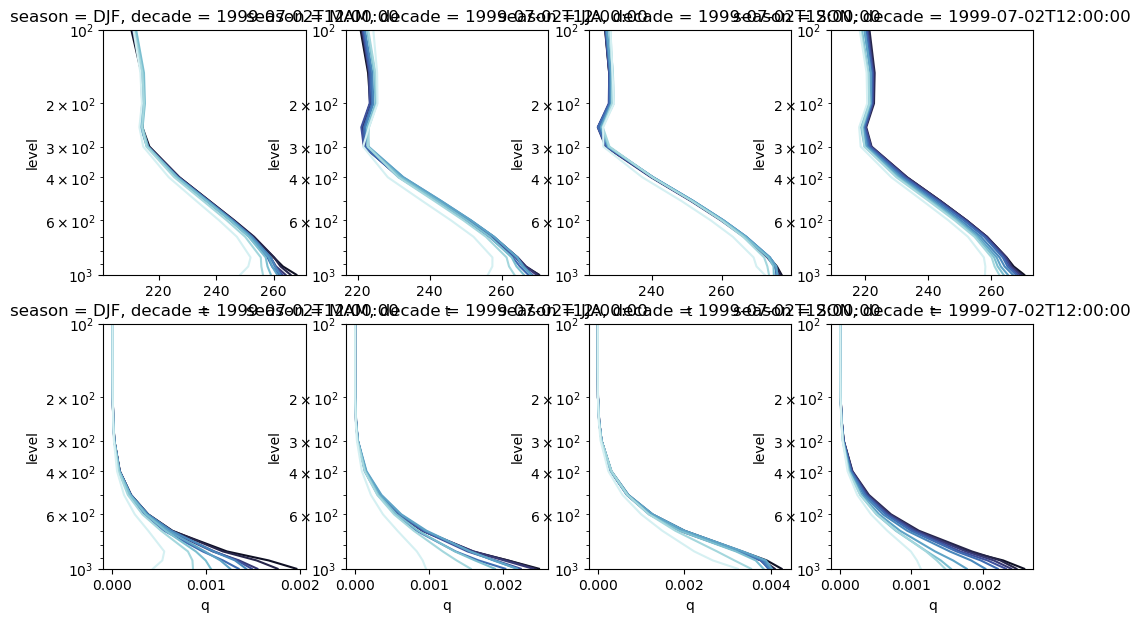

In [8]:
from cmocean import cm


for i, decade in enumerate(ds_out.decade[::2]):
    


    fig, ax = plt.subplots(2, 4, figsize=(12, 7))
    from cycler import cycler

    for a in ax.flatten():
        a.set_yscale('log')
        a.set_prop_cycle(cycler(color=cm.ice(ds_out.sea_ice_cover)))
        a.set_ylim(1000, 100)

    ds_out.isel(season=0, decade=i).t.plot(hue='sea_ice_cover', add_legend=False, y='level', ax=ax[0, 0])
    ds_out.isel(season=1, decade=i).t.plot(hue='sea_ice_cover', add_legend=False, y='level', ax=ax[0, 1])
    ds_out.isel(season=2, decade=i).t.plot(hue='sea_ice_cover', add_legend=False, y='level', ax=ax[0, 2])
    ds_out.isel(season=3, decade=i).t.plot(hue='sea_ice_cover', add_legend=False, y='level', ax=ax[0, 3])

    ds_out.isel(season=0, decade=i).q.plot(hue='sea_ice_cover', add_legend=False, y='level', ax=ax[1, 0])
    ds_out.isel(season=1, decade=i).q.plot(hue='sea_ice_cover', add_legend=False, y='level', ax=ax[1, 1])
    ds_out.isel(season=2, decade=i).q.plot(hue='sea_ice_cover', add_legend=False, y='level', ax=ax[1, 2])
    ds_out.isel(season=3, decade=i).q.plot(hue='sea_ice_cover', add_legend=False, y='level', ax=ax[1, 3])


    plt.yscale('log')
    plt.ylim(1000, 100)


In [58]:
# add units 
ds_out['t'].attrs['units'] = 'K'
ds_out['q'].attrs['units'] = 'kg/kg'

ds_to_rs = ds_out.copy()

ds_to_rs = ds_to_rs.rename({
    'level' : 'pressure_level',
    'decade' : 'valid_time'
})

ds_to_rs['pressure_level'].attrs['units'] = 'hPa'

ds_to_rs.to_netcdf('data/era5_sea_ice_to_libradtran.nc')

In [9]:
ds_trend = ds_out - ds_out.mean(dim='decade') 

In [11]:
ds_out['theta'] = ds_out['t'] * (1000 / ds_out['level'])**0.286


<Figure size 1200x1000 with 0 Axes>

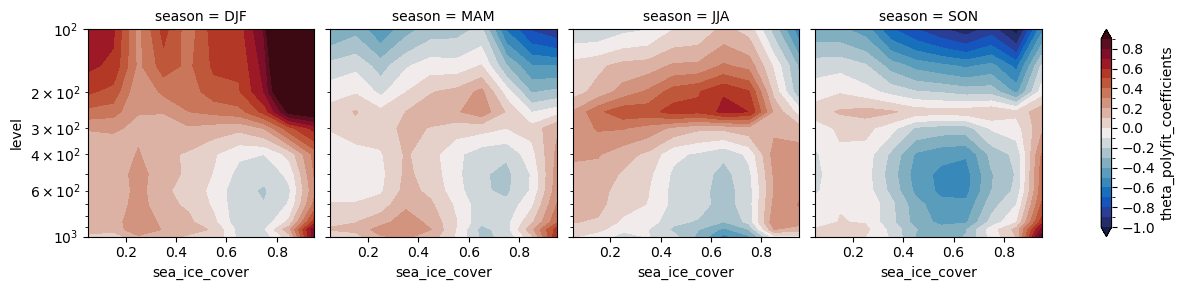

In [12]:
fig = plt.figure(figsize=(12, 10))

da_to_plot = ds_out.polyfit(dim='decade', deg=1).isel(degree=0).theta_polyfit_coefficients * (1e9 * 3600 * 24 * 365 * 10)
da_to_plot.plot.contourf(y='level', ylim=(1000, 100), yscale='log', col='season', robust=False, levels=np.arange(-1, 1, .1), cmap=cm.balance,)
plt.show()

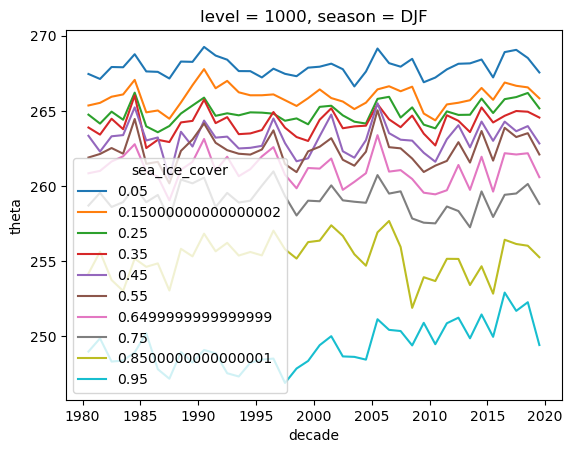

In [21]:
ds_out.isel(season=0, level=-1).theta.plot(hue='sea_ice_cover')

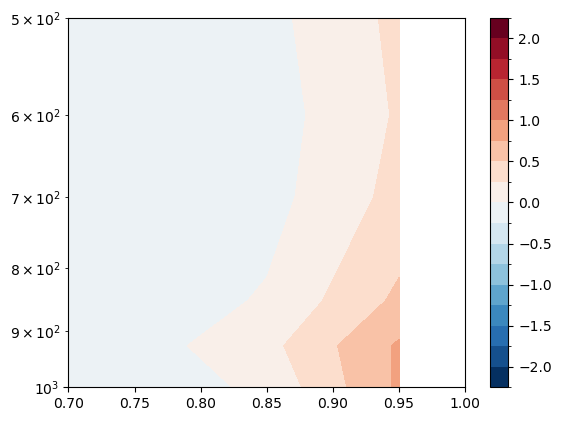

In [13]:
da_to_plot.sel(season='DJF').plot.contourf(
    ylim=(1000, 500), yscale='log', y='level', add_labels=False, levels=20, xlim=(0.7, 1)
)


<Figure size 1200x1000 with 0 Axes>

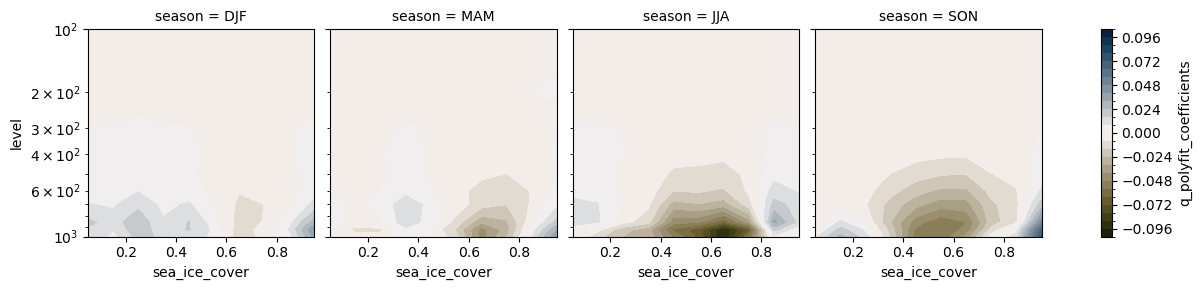

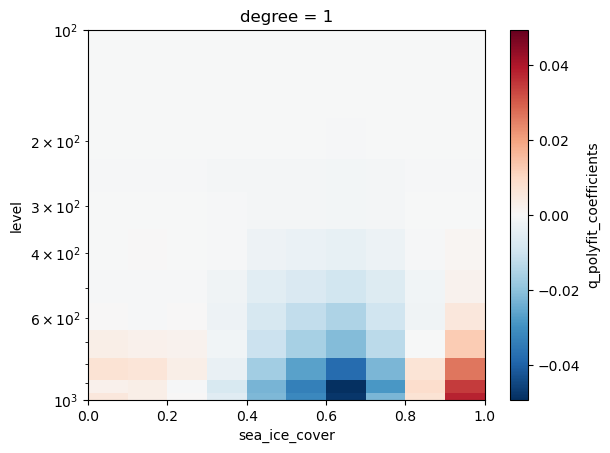

In [22]:
fig = plt.figure(figsize=(12, 10))

da_to_plot = ds_out.polyfit(dim='decade', deg=1).isel(degree=0).q_polyfit_coefficients * (1e9 * 3600 * 24 * 365 * 10) * 1000
da_to_plot.plot.contourf(y='level', ylim=(1000, 100), yscale='log', col='season', robust=False, cmap=cm.diff_r, levels=30)
plt.show()
da_to_plot.mean('season').plot(ylim=(1000, 100), yscale='log', y='level')

(1000, 700)

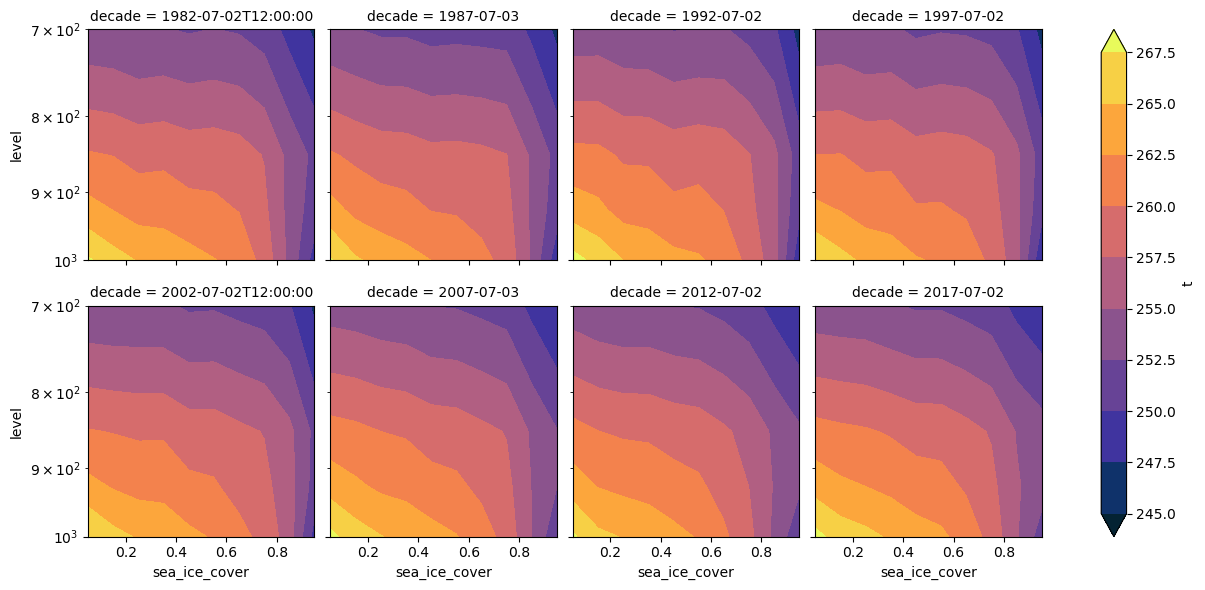

In [40]:
ds_out.t.isel(season=0).plot.contourf(
    levels=np.arange(245, 270, 2.5),    
    cmap=cm.thermal,
    col='decade', col_wrap=4, yscale='log', y='level', add_labels=False, ylim=(1000, 100))

plt.ylim(1000, 700)

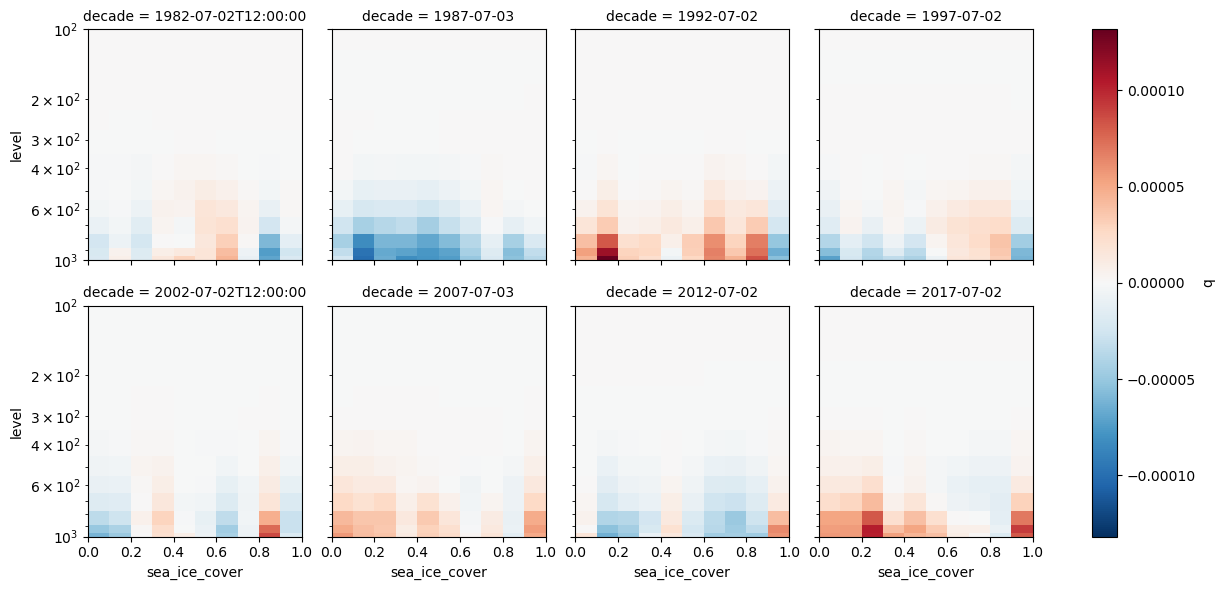

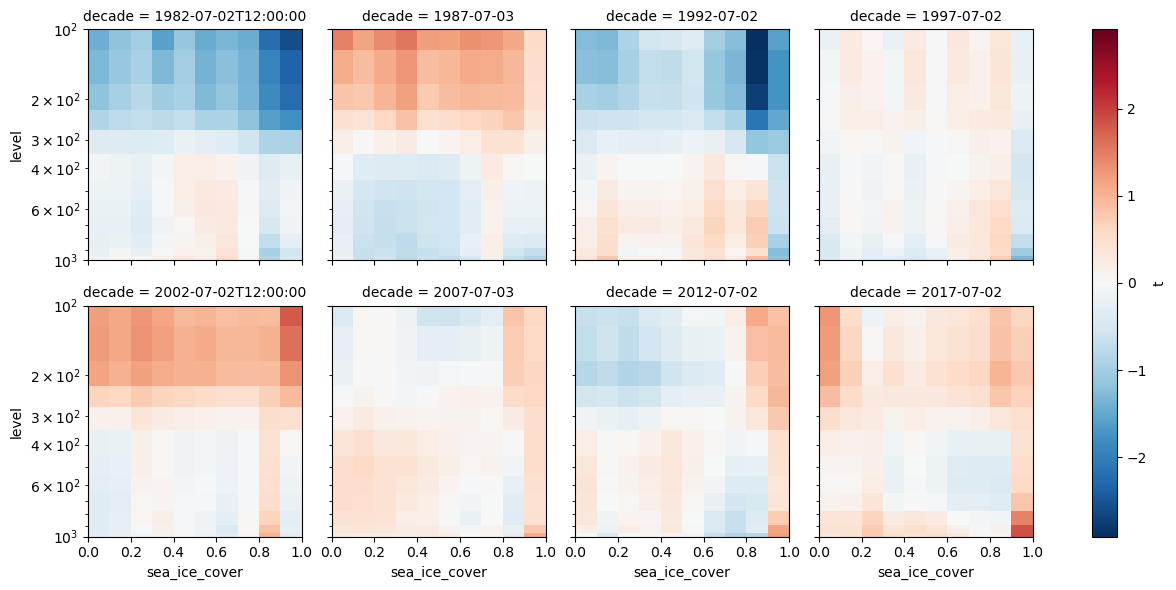

In [13]:
ds_trend.q.isel(season=0).plot(col='decade', col_wrap=4, yscale='log', y='level', add_labels=False, ylim=(1000, 100))
ds_trend.t.isel(season=0).plot(col='decade', col_wrap=4, yscale='log', y='level', add_labels=False, ylim=(1000, 100))
# set all yscales to logscale 

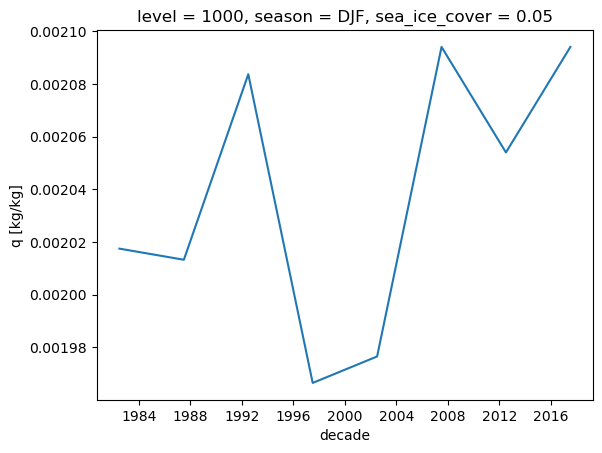

In [69]:
ds_out.q.isel(season=0, sea_ice_cover=0, level=-1).plot()


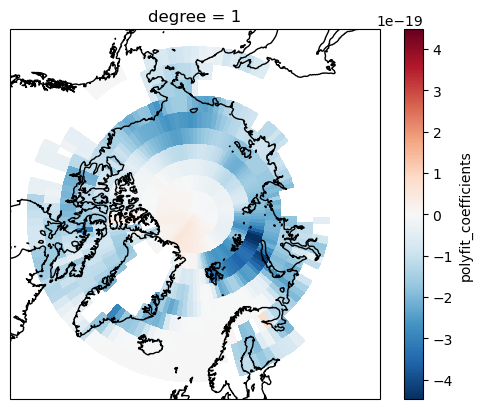

In [15]:
from cartopy import crs as ccrs
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(
    subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

ds_arctic_subset_sic.polyfit('time', deg=1).isel(degree=0)['polyfit_coefficients'].plot(x='longitude', transform=ccrs.PlateCarree(), ax=ax)
ax.coastlines()